In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('airline_passenger_satisfaction.csv')
df.shape

(129880, 24)

In [ ]:
# quick look before diving in
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


## Bivariate Analysis

In [ ]:
# encode target so i can use it in calculations easily
df['satisfied'] = (df['Satisfaction'] == 'Satisfied').astype(int)
df['satisfied'].value_counts()

,count
satisfied,
0,73452
1,56428


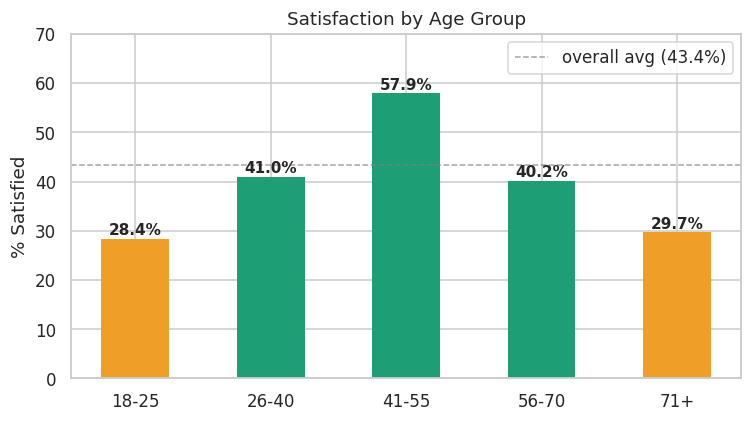

In [ ]:
# how does satisfaction change across age groups
df['age_group'] = pd.cut(df['Age'], bins=[0,25,40,55,70,100],
                         labels=['18-25','26-40','41-55','56-70','71+'])

age_sat = df.groupby('age_group', observed=True)['satisfied'].mean().mul(100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#ef9f27' if v < 40 else '#1d9e75' for v in age_sat]
bars = ax.bar(age_sat.index, age_sat.values, color=colors, edgecolor='none', width=0.5)
for bar, val in zip(bars, age_sat.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val}%', ha='center', fontsize=10, fontweight='bold')
ax.axhline(df['satisfied'].mean()*100, color='gray', linestyle='--',
           linewidth=1, alpha=0.7, label=f'overall avg ({df["satisfied"].mean()*100:.1f}%)')
ax.set_ylabel('% Satisfied')
ax.set_title('Satisfaction by Age Group')
ax.set_ylim(0, 70)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# class x travel type — this combo should be interesting
ct = df.groupby(['Class','Type of Travel'], observed=True)['satisfied'].mean().mul(100).round(1).unstack()
ct

Type of Travel,Business,Personal
Class,,
Business,72.0,11.7
Economy,29.9,10.2
Economy Plus,39.3,8.7


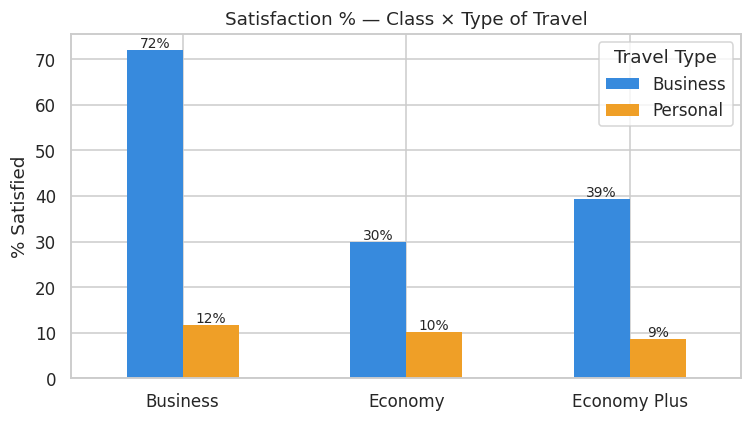

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ct.plot(kind='bar', ax=ax, color=['#378add','#ef9f27'], edgecolor='none', width=0.5)
ax.set_title('Satisfaction % — Class × Type of Travel')
ax.set_ylabel('% Satisfied')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Travel Type')
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.0f}%',
                    (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                    ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# business class + business travel = 72% satisfied
# personal travel doesnt matter what class you're in, still under 12%

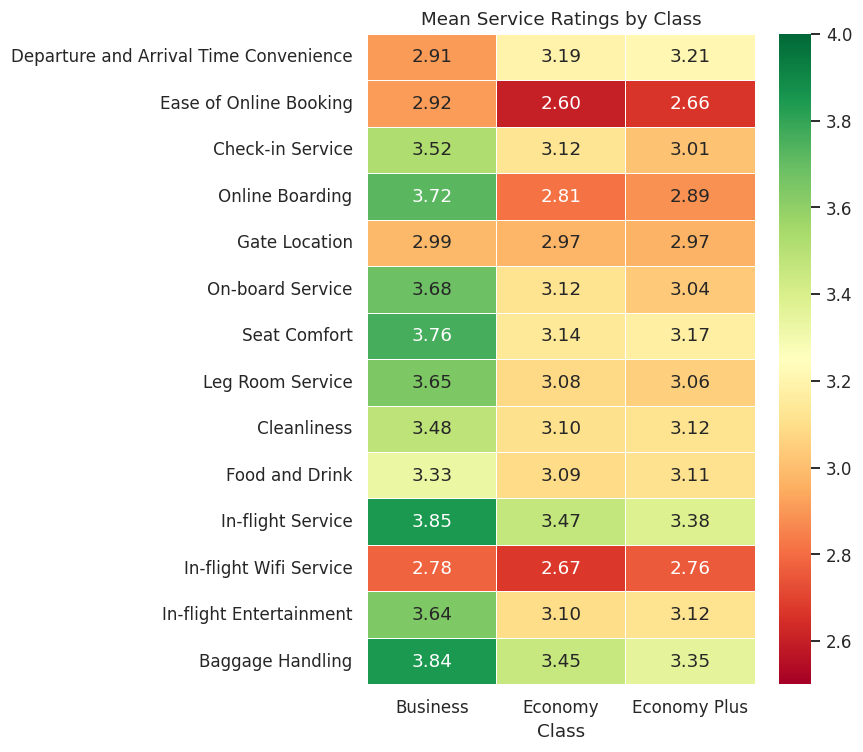

In [ ]:
# heatmap of service ratings by class
service_cols = [
    'Departure and Arrival Time Convenience', 'Ease of Online Booking',
    'Check-in Service', 'Online Boarding', 'Gate Location',
    'On-board Service', 'Seat Comfort', 'Leg Room Service',
    'Cleanliness', 'Food and Drink', 'In-flight Service',
    'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling'
]

class_means = df.groupby('Class', observed=True)[service_cols].mean().T

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(class_means, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=2.5, vmax=4.0, linewidths=0.4, ax=ax)
ax.set_title('Mean Service Ratings by Class')
plt.tight_layout()
plt.show()

## Statistical Tests

In [ ]:
# chi-square test for all categoricals — are the associations actually significant
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

rows = []
for col in cat_cols:
    table = pd.crosstab(df[col], df['Satisfaction'])
    chi2, p, dof, _ = chi2_contingency(table)
    v = np.sqrt(chi2 / (len(df) * (min(table.shape) - 1)))
    rows.append({'feature': col, 'chi2': round(chi2,1), 'p_value': round(p, 6),
                 'cramers_v': round(v, 3)})

pd.DataFrame(rows)

,feature,chi2,p_value,cramers_v
0,Gender,16.4,0.000053,0.011
1,Customer Type,4493.2,0.000000,0.186
2,Type of Travel,26282.5,0.000000,0.450
3,Class,32906.2,0.000000,0.503


In [ ]:
# which service ratings actually correlate with satisfaction
pb_rows = []
for col in service_cols:
    r, p = pointbiserialr(df[col], df['satisfied'])
    pb_rows.append({'service': col, 'r': round(r,3), 'p': round(p, 8)})

pb_df = pd.DataFrame(pb_rows).sort_values('r', ascending=False)
pb_df

,service,r,p
3,Online Boarding,0.502,0.0000
12,In-flight Entertainment,0.398,0.0000
6,Seat Comfort,0.349,0.0000
5,On-board Service,0.322,0.0000
7,Leg Room Service,0.312,0.0000
8,Cleanliness,0.307,0.0000
11,In-flight Wifi Service,0.283,0.0000
13,Baggage Handling,0.249,0.0000
10,In-flight Service,0.245,0.0000
2,Check-in Service,0.237,0.0000


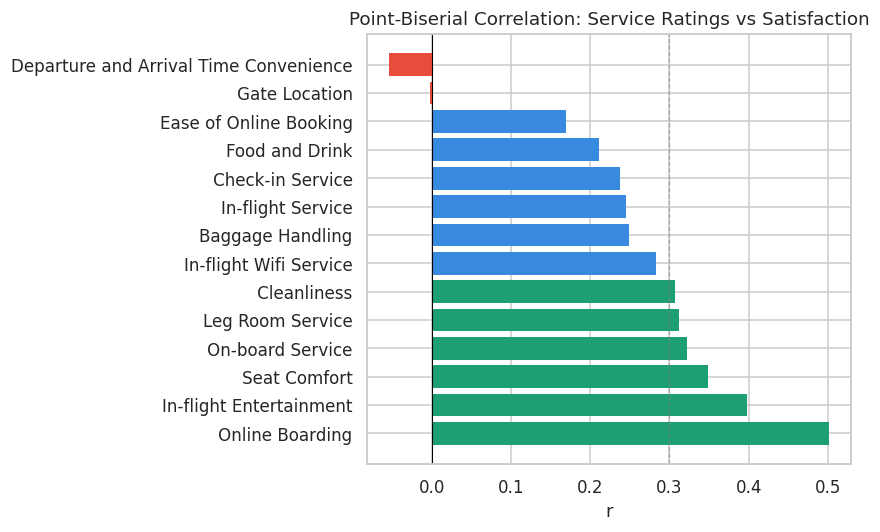

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#1d9e75' if r > 0.3 else '#378add' if r > 0.1 else '#ef9f27' if r >= 0 else '#e74c3c'
          for r in pb_df['r']]
ax.barh(pb_df['service'], pb_df['r'], color=colors, edgecolor='none')
ax.axvline(0, color='black', linewidth=0.7)
ax.axvline(0.3, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title('Point-Biserial Correlation: Service Ratings vs Satisfaction')
ax.set_xlabel('r')
plt.tight_layout()
plt.show()

# online boarding r=0.50 is way ahead of everything else

## Findings

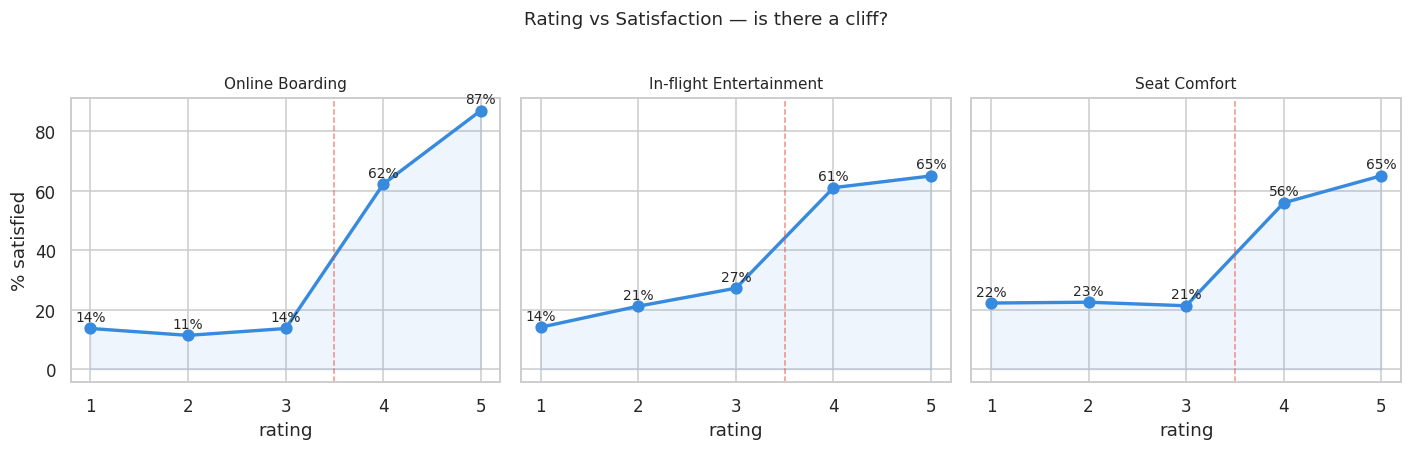

In [ ]:
# does satisfaction increase linearly with rating or is there a jump somewhere
# checking the top 3 service predictors

cliff_cols = ['Online Boarding', 'In-flight Entertainment', 'Seat Comfort']

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, col in zip(axes, cliff_cols):
    rate = df[df[col] > 0].groupby(col)['satisfied'].mean().mul(100)
    ax.plot(rate.index, rate.values, marker='o', color='#378add', linewidth=2.2, markersize=7)
    ax.fill_between(rate.index, rate.values, alpha=0.08, color='#378add')
    ax.axvline(3.5, color='#e74c3c', linestyle='--', linewidth=1, alpha=0.6)
    for x, y in zip(rate.index, rate.values):
        ax.annotate(f'{y:.0f}%', (x, y+2.5), ha='center', fontsize=9)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('rating')
    ax.set_xticks([1,2,3,4,5])

axes[0].set_ylabel('% satisfied')
plt.suptitle('Rating vs Satisfaction — is there a cliff?', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# wifi paradox — business class pays the most but rates wifi the lowest
wifi_mean = df.groupby('Class', observed=True)['In-flight Wifi Service'].mean().round(2)
print('mean wifi rating by class:')
print(wifi_mean)

all_means = df.groupby('Class', observed=True)[service_cols].mean()
print('\nbusiness class service rankings (lowest to highest):')
print(all_means.loc['Business'].sort_values())

mean wifi rating by class:
Class
Business        2.78
Economy         2.67
Economy Plus    2.76
Name: In-flight Wifi Service, dtype: float64

business class service rankings (lowest to highest):
In-flight Wifi Service                    2.775917
Departure and Arrival Time Convenience    2.907915
Ease of Online Booking                    2.915653
Gate Location                             2.985103
Food and Drink                            3.329955
Cleanliness                               3.481998
Check-in Service                          3.521010
In-flight Entertainment                   3.639350
Leg Room Service                          3.646042
On-board Service                          3.682529
Online Boarding                           3.719032
Seat Comfort                              3.763707
Baggage Handling                          3.844852
In-flight Service                         3.846268
Name: Business, dtype: float64


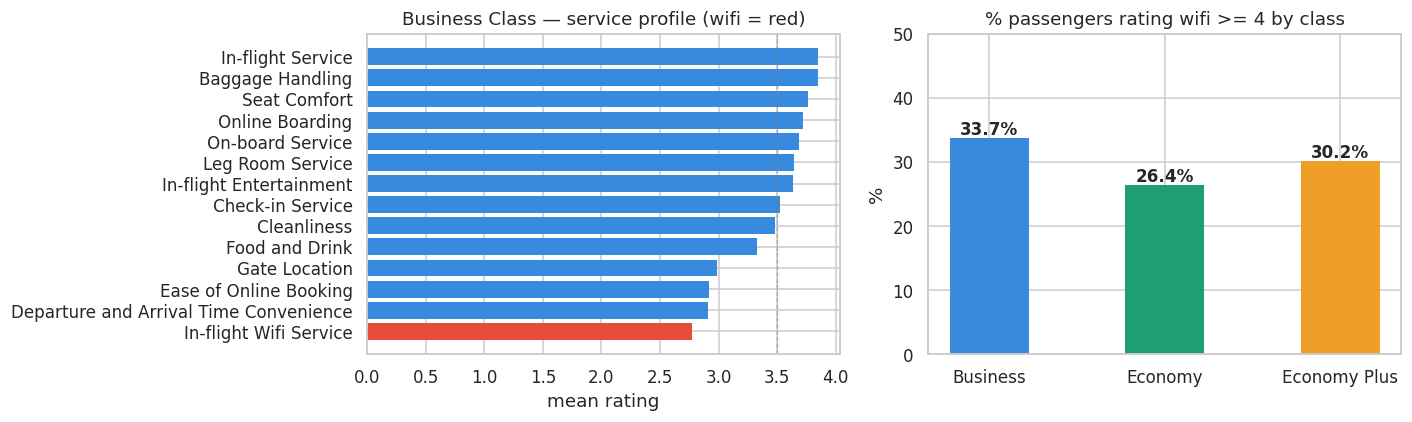

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

biz_profile = all_means.loc['Business'].sort_values()
bar_colors = ['#e74c3c' if 'Wifi' in c else '#378add' for c in biz_profile.index]
axes[0].barh(biz_profile.index, biz_profile.values, color=bar_colors, edgecolor='none')
axes[0].axvline(3.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
axes[0].set_title('Business Class — service profile (wifi = red)')
axes[0].set_xlabel('mean rating')

wifi_4plus = df.groupby('Class', observed=True).apply(
    lambda x: (x['In-flight Wifi Service'] >= 4).mean() * 100).round(1)
axes[1].bar(wifi_4plus.index, wifi_4plus.values,
            color=['#378add','#1d9e75','#ef9f27'], edgecolor='none', width=0.45)
for i, (idx, val) in enumerate(wifi_4plus.items()):
    axes[1].text(i, val + 0.5, f'{val}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('% passengers rating wifi >= 4 by class')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 50)

plt.tight_layout()
plt.show()

In [ ]:
# anomaly check — passengers satisfied despite rating services poorly
df['service_score'] = df[service_cols].replace(0, np.nan).mean(axis=1)

low_score_satisfied  = df[(df['service_score'] < 3.0) & (df['satisfied'] == 1)]
high_score_unsat     = df[(df['service_score'] > 4.0) & (df['satisfied'] == 0)]

print(f'low ratings but satisfied  : {len(low_score_satisfied)} ({len(low_score_satisfied)/len(df)*100:.1f}%)')
print(f'high ratings but unhappy   : {len(high_score_unsat)} ({len(high_score_unsat)/len(df)*100:.1f}%)')

low ratings but satisfied  : 5583 (4.3%)
high ratings but unhappy   : 2011 (1.5%)


In [ ]:
# who are these anomaly passengers
segs = {
    'low score + satisfied': low_score_satisfied,
    'high score + dissatisfied': high_score_unsat
}

for name, seg in segs.items():
    print(f'\n--- {name} ({len(seg)} pax) ---')
    print('class dist:        ', seg['Class'].value_counts(normalize=True).round(2).to_dict())
    print('customer type:     ', seg['Customer Type'].value_counts(normalize=True).round(2).to_dict())
    print('travel type:       ', seg['Type of Travel'].value_counts(normalize=True).round(2).to_dict())
    print(f'avg age:            {seg["Age"].mean():.1f}')
    print(f'avg flight dist:    {seg["Flight Distance"].mean():.0f} miles')


--- low score + satisfied (5583 pax) ---
class dist:         {'Business': 0.63, 'Economy': 0.31, 'Economy Plus': 0.06}
customer type:      {'Returning': 0.89, 'First-time': 0.11}
travel type:        {'Business': 0.86, 'Personal': 0.14}
avg age:            40.1
avg flight dist:    1378 miles

--- high score + dissatisfied (2011 pax) ---
class dist:         {'Economy': 0.72, 'Business': 0.19, 'Economy Plus': 0.09}
customer type:      {'Returning': 0.82, 'First-time': 0.18}
travel type:        {'Personal': 0.78, 'Business': 0.22}
avg age:            37.4
avg flight dist:    773 miles


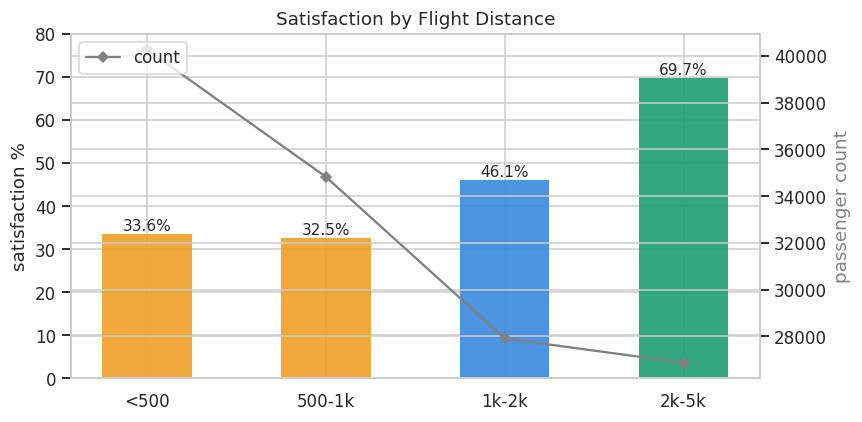

In [ ]:
# flight distance vs satisfaction
df['dist_bucket'] = pd.cut(df['Flight Distance'],
                           bins=[0,500,1000,2000,5000,10000],
                           labels=['<500','500-1k','1k-2k','2k-5k','5k+'])

dist_stats = df.groupby('dist_bucket', observed=True).agg(
    sat_pct=('satisfied','mean'),
    n=('satisfied','count')
).reset_index()
dist_stats['sat_pct'] = dist_stats['sat_pct'] * 100

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
bars = ax1.bar(dist_stats['dist_bucket'], dist_stats['sat_pct'],
               color=['#ef9f27','#ef9f27','#378add','#1d9e75','#1d9e75'],
               edgecolor='none', width=0.5, alpha=0.9, label='sat %')
ax2.plot(dist_stats['dist_bucket'], dist_stats['n'],
         marker='D', color='gray', linewidth=1.5, markersize=5, label='count')
for i, row in dist_stats.iterrows():
    ax1.text(i, row['sat_pct'] + 0.8, f"{row['sat_pct']:.1f}%", ha='center', fontsize=10)
ax1.set_ylabel('satisfaction %')
ax2.set_ylabel('passenger count', color='gray')
ax1.set_title('Satisfaction by Flight Distance')
ax1.set_ylim(0, 80)
ax2.legend(loc='upper left')
plt.tight_layout()
plt.show()

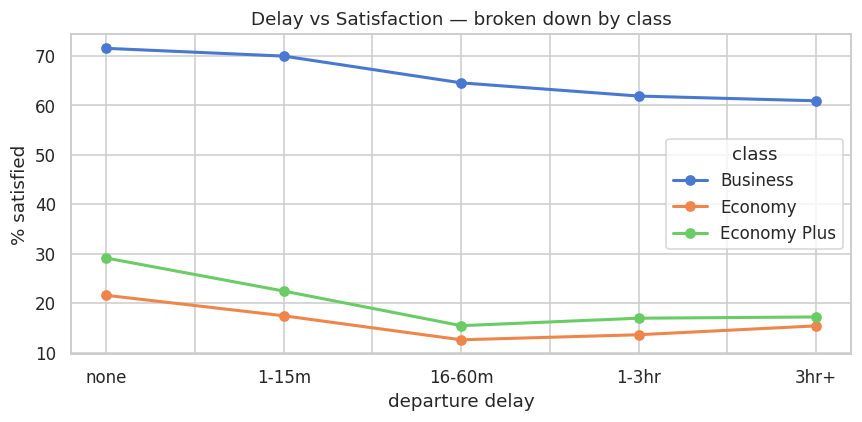

In [ ]:
# do delays hurt economy class passengers more than business?
df['delay_cat'] = pd.cut(df['Departure Delay'],
                         bins=[-1,0,15,60,200,10000],
                         labels=['none','1-15m','16-60m','1-3hr','3hr+'])

delay_class = df.groupby(['delay_cat','Class'], observed=True)['satisfied'].mean().mul(100).unstack()

fig, ax = plt.subplots(figsize=(8, 4))
delay_class.plot(ax=ax, marker='o', linewidth=2, markersize=6)
ax.set_title('Delay vs Satisfaction — broken down by class')
ax.set_xlabel('departure delay')
ax.set_ylabel('% satisfied')
ax.legend(title='class')
plt.tight_layout()
plt.show()

# economy plus drops the most with delays — premium expectation without business class recovery